# Part1: Text Detection

In [1]:
import paddle
paddle.utils.run_check()
#from PaddleOCR import PaddleOCR, draw_ocr
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
%matplotlib inline

Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 CPU.


c:\Users\User\miniconda3\envs\paddlelite\lib\site-packages\paddle\fluid\executor.py:1585: UserWarning: Standalone executor is not used for data parallel
  UserWarning)


PaddlePaddle works well on 2 CPUs.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


### Generate Rotated images to fit the model

In [ ]:
for i in range(9, 10):
    img_path=f'./dataset/train/00{i}.jpg'
    image = Image.open(img_path).convert('RGB')
    image = Image.Image.rotate(image, 270)
    Image.Image.save(image, f'./dataset/rotated/00{i}.png')

## Testing detection on single image

[2025/04/12 03:04:57] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='C:\\Users\\User/.paddleocr/whl\\cls\\ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='C:\\Users\\User/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_sc

[2025/04/12 03:04:58] ppocr WARNING: Since the angle classifier is not initialized, the angle classifier will not be uesd during the forward process


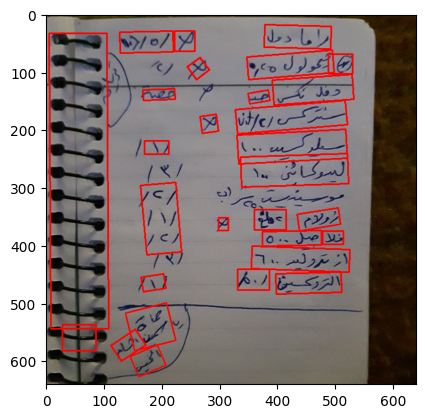

In [6]:

img_path=r'.\dataset\resized\test\011.jpg'
model_path=r'D:\Order_API\image_order\PharmaOCR\pretrain_models\ch_ppocr_mobile_v2.0_det_slim_infer'#r'.\output\det_db_inference'

ocr = PaddleOCR(rec_model_dir=model_path, lang='ar', use_gpu=False, use_angle_cls=False)
result = ocr.ocr(img_path, rec=False) 
#print(result)       
image = Image.open(img_path).convert('RGB')
for box in result:
    im_show = draw_ocr(image, box)
    image = im_show
plt.figure()
plt.imshow(im_show);


## Preprocessing Detected Boxes

In [ ]:
import os
from PaddleOCR import PaddleOCR
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def centeroid(list):
    arr = np.asanyarray(list)
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

# Configuration
image_dir = r".\dataset\rotated"
model_path = r'.\output\det_db_inference'
output_dir = r".\dataset\merged_results"
os.makedirs(output_dir, exist_ok=True)

# Threshold parameters (idx0 => horizontal, idx1 => vertical)
vertical_threshold = .025  # Max vertical distance to consider boxes on the same line
horizontal_threshold = .2  # Max horizontal gap between boxes to merge
size_tolerence = 20
search_ver_threshold = 100

# Initialize PaddleOCR
ocr = PaddleOCR(rec_model_dir=model_path, lang='ar', use_gpu=False, use_angle_cls=True)

def merge_boxes(boxes, vertical_threshold, horizontal_threshold):
    """
    Merge boxes that are aligned horizontally and within the specified thresholds.
    """
    if not boxes:
        return []

    # Sort boxes by their vertical position (top y-coordinate)
    boxes = sorted(boxes, key=lambda x: centeroid(x)[1])

    merged_boxes = []
    current_box = list(boxes[0])
    current_box_width = abs(current_box[0][0] - current_box[1][0])
    current_box_hight = abs(current_box[0][1] - current_box[3][1])
    c = 0
    while current_box_hight > current_box_width or current_box_width < size_tolerence:
        c+=1
        current_box = list(boxes[c])
        current_box_width = abs(current_box[0][0] - current_box[1][0])
        current_box_hight = abs(current_box[0][1] - current_box[3][1])
    
    while c < len(boxes):
        candidates = [box for box in boxes[c+1:] if abs(centeroid(box)[1] - centeroid(current_box)[1]) < search_ver_threshold]
        for box in candidates:
            # Check if the next box is on the same line (vertical threshold)
            box_width = abs(box[0][0] - box[1][0])
            box_hight = abs(box[0][1] - box[3][1])
            current_box_width = abs(current_box[0][0] - current_box[1][0])
            current_box_hight = abs(current_box[0][1] - current_box[3][1])
            
            if box_hight > box_width or box_width < size_tolerence:
                # false detection
                continue
            
            # box sequence: top-left => top-right => down-left => down-right
            horizontal_threshold = 1.5* max(box_width, current_box_width)
            vertical_threshold = .5*max(box_hight, current_box_hight)
                
            if abs(centeroid(box)[1] - centeroid(current_box)[1]) < vertical_threshold:
                # box_to_right = centeroid(box)[0] - centeroid(current_box)[0] > 0
                # if (not box_to_right and abs(box[0][0] - current_box[1][0]) < max(box_width, current_box_width)) \
                #     or (box_to_right and abs(box[1][0] - current_box[0][0]) < max(box_width, current_box_width)):
                #     # box contained in current box
                #     continue
                
                if abs(centeroid(box)[0] - centeroid(current_box)[0]) < .25*max(box_width, current_box_width):
                    continue
                
                # Check if the next box is close enough horizontally to merge
                if abs(centeroid(box)[0] - centeroid(current_box)[0]) < horizontal_threshold:
                    # Merge boxes by expanding the current box
                    current_box[0][0] = min(current_box[0][0], box[0][0])  # Leftmost x
                    current_box[1][0] = max(current_box[1][0], box[1][0])  # Rightmost x
                    current_box[2][0] = max(current_box[2][0], box[2][0])  # Rightmost x
                    current_box[3][0] = min(current_box[3][0], box[3][0])  # Leftmost x
                    current_box[0][1] = min(current_box[0][1], box[0][1])  # Topmost y
                    current_box[1][1] = min(current_box[1][1], box[1][1])  # Topmost y
                    current_box[2][1] = max(current_box[2][1], box[2][1])  # Bottommost y
                    current_box[3][1] = max(current_box[3][1], box[3][1])  # Bottommost y
                else:
                    # Add the current merged box and start a new one
                    merged_boxes.append(current_box)
                    current_box = list(box)
            else:
                # Add the current merged box and start a new one
                merged_boxes.append(current_box)
                current_box = list(box)

    # Add the last merged box
    merged_boxes.append(current_box)

    return merged_boxes

def process_image(image_path, output_path):
    # Run detection
    result = ocr.ocr(image_path, rec=False)
    boxes = [box for box in result[0]]  # Extract bounding boxes

    # Merge boxes
    merged_boxes = merge_boxes(boxes, vertical_threshold, horizontal_threshold)

    # Visualize results
    image_orig = Image.open(image_path).convert('RGB')
    draw_orig = ImageDraw.Draw(image_orig)
    image_merg = Image.open(image_path).convert('RGB')
    draw_merg = ImageDraw.Draw(image_merg)

    # Draw original boxes in red
    for box in boxes:
        draw_orig.polygon([tuple(point) for point in box], outline='red', width=7)

    # Draw merged boxes in green
    for box in merged_boxes:
        draw_merg.polygon([tuple(point) for point in box], outline='green', width=7)

    # Save and display
    image_merg.save(output_path)
    _, axarr = plt.subplots(1,2, figsize=(8, 16))
    axarr[1].imshow(image_orig)
    axarr[0].imshow(image_merg)
    plt.title(f"Merged Boxes: {os.path.basename(image_path)}")
    plt.show()

# Process all images in the directory
for filename in os.listdir(image_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_path = os.path.join(image_dir, filename)
        output_path = os.path.join(output_dir, filename)
        process_image(image_path, output_path)

print(f"Processing complete. Results saved to: {output_dir}")

[2025/03/23 15:25:20] ppocr DEBUG: Namespace(alpha=1.0, alphacolor=(255, 255, 255), benchmark=False, beta=1.0, binarize=False, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='C:\\Users\\User/.paddleocr/whl\\cls\\ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='C:\\Users\\User/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_d

# Part2: Text Classification

In [1]:
import os
import cv2
import numpy as np
import paddle
from paddle.io import Dataset, DataLoader
from paddle.vision.transforms import Compose, Resize, Normalize
from paddle.nn import Linear, CrossEntropyLoss, Dropout, Conv2D, AvgPool2D
from paddle.optimizer import Adam
from paddle.metric import Accuracy
from matplotlib import pyplot as plt

### Step 1: Data Preparation

In [ ]:
# Configuration
data_dir = r".\dataset"   # path to label txt files (train, test, val)
save_data_dir = r".\dataset\multi_cls"
output_dir = r".\dataset\classification"
image_size = (32, 64)  # Resize all text regions to this size
num_classes = 4  # Number of unique classes
batch_size = 16
epochs = 256
learning_rate = 0.00001

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Class mapping (word to label)
class TextClassificationDataset(Dataset):
    class_mapping = {}
    class_counter = 0
    
    def __init__(self, data_dir, split, transform=None, update_mapping=True, augment=False):
        self.data_dir = os.path.join(data_dir, split)
        self.label_dir = os.path.join(data_dir, f"{split}.txt")
        self.transform = transform
        self.update_mapping = update_mapping
        self.augment = augment
        self.split = split
        self.samples = self._load_samples()
        

    def _load_samples(self):
        samples = []
        # Read the label file
        with open(self.label_dir, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        # First pass to load original samples and build mapping
        for line in lines:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue

            img_path = parts[0]
            annotations = eval(parts[1])

            # Load the image
            #image = cv2.imread(os.path.join(data_dir, img_path), cv2.IMREAD_GRAYSCALE)
            #image = image.astype(np.float32)/255.0
            image = cv2.imread(os.path.join(data_dir, img_path))

            if image is None:
                print(f"Warning: Could not load image {os.path.join(data_dir, img_path)}. Skipping.")
                continue

            # Process each annotation
            for ann in annotations:
                transcription = ann['transcription']
                points = ann['points']

                # Update class mapping
                if transcription not in self.class_mapping:
                    if self.update_mapping:
                        self.class_mapping[transcription] = self.class_counter
                        self.class_counter += 1
                    else:
                        # Skip unknown classes for val/test
                        continue

                # Crop the text region
                x_coords = [p[0] for p in points]
                y_coords = [p[1] for p in points]
                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)
                cropped_image = image[y_min:y_max, x_min:x_max]

                # Skip invalid regions
                if cropped_image.size == 0:
                    print(f"Warning: Invalid region in {img_path}. Skipping.")
                    continue
                
                if cropped_image.shape[0] > cropped_image.shape[1]:
                    cropped_image = cv2.rotate(cropped_image, cv2.ROTATE_90_CLOCKWISE)
                    
                # Add to samples
                label = self.class_mapping[transcription]
                samples.append((cropped_image.copy(), label))
                
        # Second pass for data augmentation (only for training)
        if self.augment:
            class_counts = {}
            for _, label in samples:
                class_counts[label] = class_counts.get(label, 0) + 1
            
            if class_counts:
                max_count = max(class_counts.values())
                augmented_samples = []

                for label, count in class_counts.items():
                    #print(f"Label {label} has {class_counts[label]} samples")
                    needed = max_count - count
                    if needed <= 0:
                        continue
                    
                    # Get class samples
                    class_samples = [s for s in samples if s[1] == label]
                    num_class_samples = len(class_samples)
                    
                    # Calculate augmentation per sample
                    per_sample = needed // num_class_samples
                    remainder = needed % num_class_samples

                    for i, (image, lbl) in enumerate(class_samples):
                        num_augment = per_sample + 1 if i < remainder else per_sample
                        
                        for _ in range(num_augment):
                            # Apply random rotation and scaling
                            angle = np.random.uniform(-10, 10)
                            scale = np.random.uniform(1.2, 1.5)
                            
                            # Generate augmented image
                            h, w = image.shape[1:]
                            center = (w//2, h//2)
                            M = cv2.getRotationMatrix2D(center, angle, scale)
                            augmented_img = cv2.warpAffine(
                                image, M, (w, h), 
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_REPLICATE
                            )
                            augmented_samples.append((augmented_img, lbl))

                samples.extend(augmented_samples)
                
        if self.split:
            with open(os.path.join(save_data_dir, f"{self.split}.txt"), 'w', encoding='utf-8') as f:
                for idx, (img, label) in enumerate(samples):
                    # image format: HWC BGR                                        
                    img_path = os.path.join(save_data_dir, self.split, f"{idx}.png")
                    cv2.imwrite(img_path, img)
                    
                    # Write annotation
                    img_path = os.path.join(save_data_dir, self.split, f"{idx}.png").replace('\\', '/')
                    for text, lbl in self.class_mapping.items():  
                        if lbl == label:
                            text_label = text
                    line = f"{self.split}/{idx}.png\t{label}"
                    f.write(line + '\n')
        
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image, label = self.samples[idx]
        
        # Apply transformations
        if self.transform:
            # Convert to 3 channels for compatibility with paddle normalization
            if len(image.shape) == 2:
                image = np.expand_dims(image, axis=-1)            
            image = self.transform(image)
            image = image.transpose((2, 0, 1))  # HWC to CHW
            
        return image.astype('float32'), np.array(label, dtype='int64')

# Create datasets with proper settings
transform = Compose([
    Resize(image_size),
    Normalize(mean=[0.5], std=[0.5])  # Add channel dimension
])

# First create training dataset to build class mapping
train_dataset = TextClassificationDataset(
    data_dir, split='train', 
    transform=transform, 
    update_mapping=True,
    augment=True  # Enable augmentation for training
)

# Then create validation and test datasets using existing mapping
val_dataset = TextClassificationDataset(
    data_dir, 'val',
    transform=transform,
    update_mapping=False,
    augment=False
)

test_dataset = TextClassificationDataset(
    data_dir, 'test',
    transform=transform,
    update_mapping=False,
    augment=False
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
class_mapping = train_dataset.class_mapping.items()
# image, label = val_dataset.__getitem__(10)
# plt.imshow(image)
# for trans, lbl in train_dataset.class_mapping.items():  
#     if lbl == label:
#         print(trans)

### Testing data augmetation

In [ ]:
from matplotlib import pyplot as plt
samples = TextClassificationDataset(data_dir, 'train', augment=True)._load_samples()

plt.figure(figsize=(50, 25))
for i, sample in enumerate(samples[-10:]):
    img_sample = np.asarray(sample[0])
    # Display results
    plt.subplot(50, 1, i+1)
    plt.imshow(img_sample, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Step 2: Define the Fully Connected Neural Network (FCNN)

In [23]:
class TextClassifier(paddle.nn.Layer):
    def __init__(self, input_size, num_classes):
        super(TextClassifier, self).__init__()
        self.flatten = paddle.nn.Flatten()
        self.conv0 = Conv2D(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                stride=4,
                padding=2,
                groups=1,
                bias_attr=False,
                weight_attr=paddle.ParamAttr(trainable=False))
        self.conv1 = Conv2D(
                in_channels=8,
                out_channels=64,
                kernel_size=3,
                stride=4,
                padding=2,
                groups=1,
                bias_attr=False,
                weight_attr=paddle.ParamAttr(trainable=False))
        self.pool2d_avg = AvgPool2D(
            kernel_size=2, stride=2, padding=0, ceil_mode=True)
        self.fc0 = Linear(384, 64)
        self.fc1 = Linear(64, 64)
        self.fc2 = Linear(64, num_classes)
        #self.fc1 = Linear(input_size, 512)
        self.do1 = Dropout(0.1)
        #self.fc2 = Linear(512, 512)
        self.do2 = Dropout(0.1)
        #self.fc3 = Linear(512, 256)
        #self.fc4 = Linear(256, num_classes)
        self.relu = paddle.nn.ReLU()

    def forward(self, x):
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.pool2d_avg(x)
        x = self.flatten(x)
        #x = self.do1(x)
        x = self.relu(self.fc0(x))
        #x = self.do2(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        # x = self.flatten(x)
        # x = self.relu(self.fc1(x))
        # #x = self.do1(x)
        # x = self.relu(self.fc2(x))
        # #x = self.do2(x)
        # x = self.relu(self.fc3(x))
        # x = self.fc4(x)
        return x

# Initialize model
input_size = image_size[0] * image_size[1]  # Flattened image size
model = TextClassifier(input_size, num_classes)

### Step 3: Training the Model

In [32]:
# Loss and optimizer
criterion = CrossEntropyLoss()
optimizer = Adam(learning_rate=learning_rate*50, parameters=model.parameters())

# Training loop
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()
        optimizer.clear_grad()

        # Metrics
        train_loss += loss.numpy()
        train_acc += np.mean(Accuracy().compute(outputs, labels).numpy())

    # Validation
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    for images, labels in val_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.numpy()
        val_acc += np.mean(Accuracy().compute(outputs, labels).numpy())

    # Print epoch results
    print(f"Epoch [{epoch + 1}/{epochs}]")
    print(f"Train Loss: {train_loss / len(train_loader)}, Train Acc: {train_acc / len(train_loader)}")
    print(f"Val Loss: {val_loss / len(val_loader)}, Val Acc: {val_acc / len(val_loader)}")

Epoch [1/256]
Train Loss: 0.7268614525742391, Train Acc: 0.7904411764705882
Val Loss: 2.302411158879598, Val Acc: 0.6362179517745972
Epoch [2/256]
Train Loss: 0.5498001010102385, Train Acc: 0.7941176470588235
Val Loss: 2.2114466494984097, Val Acc: 0.6153846184412638
Epoch [3/256]
Train Loss: 0.5526726149460849, Train Acc: 0.7904411764705882
Val Loss: 4.429757701026069, Val Acc: 0.4471153848701053
Epoch [4/256]
Train Loss: 0.5731038657181403, Train Acc: 0.7757352941176471
Val Loss: 5.457933955722385, Val Acc: 0.426282051536772
Epoch [5/256]
Train Loss: 0.633669376373291, Train Acc: 0.7959558823529411
Val Loss: 3.240585115220812, Val Acc: 0.49252136879497105
Epoch [6/256]
Train Loss: 0.41206296226557565, Train Acc: 0.7977941176470589
Val Loss: 2.851730055279202, Val Acc: 0.5443376070923276
Epoch [7/256]
Train Loss: 0.40283162146806717, Train Acc: 0.8106617647058824
Val Loss: 2.789227777057224, Val Acc: 0.551282051536772
Epoch [8/256]
Train Loss: 0.39166691176155033, Train Acc: 0.81617647

### Resetting Last layers for retraining

In [26]:
model.fc0.weight.set_value(paddle.to_tensor(np.asarray(np.random.rand(384, 64), dtype='float32')))
model.fc1.weight.set_value(paddle.to_tensor(np.asarray(np.random.rand(64, 64), dtype='float32')))

In [25]:
model_path = "./dataset/classification/text_classifier.pdparams"
model_state_dict = paddle.load(model_path)
model.set_state_dict(model_state_dict)

([], [])

### Step 4: Testing the Model

In [ ]:
model.eval()
test_acc = 0.0

for images, labels in test_loader:
    outputs = model(images)
    test_acc += np.mean(Accuracy().compute(outputs, labels).numpy())
  
#print(images[0])
print(f"Test Accuracy: {test_acc / len(test_loader)}")

Test Accuracy: 0.6169871820343865


### Save model parameters to disk

In [21]:
output_dir=r".\dataset\classification"
paddle.save(model.state_dict(), os.path.join(output_dir, 'text_classifier.pdparams'))


### Generate Inference files on disk

In [19]:
from paddle.jit import to_static

# Prepare model for inference
model.eval()

# Create example input (match your input dimensions)
#example_input = paddle.randn([1, 1, 32, 64], dtype='float32')  # [batch, channel, height, width]
other_shape = [
            paddle.static.InputSpec(
                shape=[None, 1, 32, 64], dtype="float32"),
        ]
# Export to inference format
paddle.jit.save(
    layer=to_static(model, input_spec=other_shape),
    path=r'.\output\classification\text_classifier',
)

## Load the model & Test on test spilt

In [ ]:
import os
import cv2
import numpy as np
import paddle
import matplotlib.pyplot as plt
from paddle.nn import Linear, Conv2D, AvgPool2D
from paddle.vision.transforms import Compose, Resize, Normalize

# Configuration
model_path = "./dataset/classification/text_classifier.pdparams"  # Path to saved model
test_dir = "./dataset/resized/test"       # Directory containing test images
test_label_file = "./dataset/test.txt"    # Test annotations file
image_size = (32, 64)                     # Must match training size
num_classes = 17                         # Must match training classes

# Define the same model architecture used during training
class TextClassifier(paddle.nn.Layer):
    def __init__(self, input_size, num_classes):
        super(TextClassifier, self).__init__()
        self.flatten = paddle.nn.Flatten()
        self.conv0 = Conv2D(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                stride=2,
                padding=1,
                groups=1,
                bias_attr=False)
        self.conv1 = Conv2D(
                in_channels=8,
                out_channels=64,
                kernel_size=3,
                stride=2,
                padding=1,
                groups=1,
                bias_attr=False)
        self.pool2d_avg = AvgPool2D(
            kernel_size=2, stride=2, padding=0, ceil_mode=True)
        self.fc0 = Linear(2048, 64)
        self.fc1 = Linear(64, num_classes)
        #self.fc1 = Linear(input_size, 512)
        #self.do1 = Dropout(0.1)
        #self.fc2 = Linear(512, 512)
        #self.do2 = Dropout(0.1)
        #self.fc3 = Linear(512, 256)
        #self.fc4 = Linear(256, num_classes)
        self.relu = paddle.nn.ReLU()

    def forward(self, x):
        x = self.conv0(x)
        x = self.conv1(x)
        x = self.pool2d_avg(x)
        x = self.flatten(x)
        x = self.relu(self.fc0(x))
        x = self.fc1(x)
        # x = self.flatten(x)
        # x = self.relu(self.fc1(x))
        # #x = self.do1(x)
        # x = self.relu(self.fc2(x))
        # #x = self.do2(x)
        # x = self.relu(self.fc3(x))
        # x = self.fc4(x)
        return x

# Initialize model
input_size = image_size[0] * image_size[1]
model = TextClassifier(input_size, num_classes)

# Load saved model weights
model_state_dict = paddle.load(model_path)
model.set_state_dict(model_state_dict)

model.eval()  # Set to evaluation mode

# Define the same transforms used during training
transform = Compose([
    Resize(image_size),
    Normalize(mean=[0.5], std=[0.5])
])

def load_test_samples(label_file):
    """Load test samples with their ground truth labels"""
    samples = []
    with open(label_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            img_path = parts[0]
            annotations = eval(parts[1].replace("'", '"'))
            samples.append((img_path, annotations))
    return samples

def predict_and_visualize(model, test_samples, num_samples=5):
    """Make predictions and visualize results"""
    plt.figure(figsize=(125, 90))
    
    for i in range(min(num_samples, len(test_samples))):
        img_path, annotations = test_samples[i]
        image = cv2.imread(os.path.join('./dataset',img_path), cv2.IMREAD_GRAYSCALE)
        image = image.astype(np.float32)/255.0
        
        # Process each text region in the image
        for _, ann in enumerate(annotations):
            points = np.array(ann['points'])
            x_min, y_min = points.min(axis=0)
            x_max, y_max = points.max(axis=0)
            cropped = image[y_min:y_max, x_min:x_max]
            
            if cropped.size == 0:
                continue
                
            # Transform and predict
            cropped = transform(cropped)
            cropped = paddle.to_tensor(cropped[np.newaxis, ...])  # Add batch dim
            logits = model(cropped)
            pred_class = paddle.argmax(logits).numpy()
            pred_prob = paddle.nn.functional.softmax(logits)[0, pred_class].numpy()
            
            # Get ground truth
            gt_class = ann['transcription']
            
            # Draw on original image
            image = cv2.rectangle(
                image, 
                (x_min, y_min), (x_max, y_max),
                (0, 1, 0) if str(pred_class) == gt_class else (1, 1, 1),
                2
            )
            for trans, lbl in train_dataset.class_mapping.items():  
                if lbl == pred_class:
                    pred = trans
            label = f"Pred: {pred} ({pred_prob:.2f}) | GT: {gt_class}"
            image = cv2.putText(
                image, label, (x_min, y_min-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (1, 0, 0), 1
            )
        
        # Display results
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Load test samples
test_samples = load_test_samples(test_label_file)

# Visualize predictions
predict_and_visualize(model, test_samples, num_samples=5)

NameError: name 'train_dataset' is not defined

<Figure size 12500x9000 with 0 Axes>

## Run the Camera Test

In [ ]:
from paddle.vision.transforms import Compose, Resize, Normalize
from PaddleOCR import PaddleOCR
import cv2
import numpy as np

def classify_region(image: np.ndarray, boxes: list):
    
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    
    if(not boxes[0]):
        cv2.imshow('image', image)
        return
       
    transform = Compose([
    Resize((32, 64)),
    Normalize(mean=[0.5], std=[0.5])
    ])            
    show_image = image.copy()
    for box in boxes[0]:
        points = np.array(box, dtype=np.uint16)
        x_min, y_min = points.min(axis=0)
        x_max, y_max = points.max(axis=0)
        cropped = image[y_min:y_max, x_min:x_max]
        
        if cropped.size == 0:
            continue
        
        if cropped.shape[0] < 24 or cropped.shape[1] < 48:
            continue
        
        cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
        cropped = cropped.astype(np.float32)/255.0
            
        # Transform and predict
        cropped = transform(cropped)
        cropped = paddle.to_tensor(cropped[np.newaxis, ...])  # Add batch dim
        logits = model(cropped)
        pred_class = paddle.argmax(logits).numpy()
        pred_prob = paddle.nn.functional.softmax(logits)[0, pred_class].numpy()
        
        # Draw the bounding box
        show_image = cv2.rectangle(show_image, 
                (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        # Draw the label
        for trans, lbl in class_mapping:  
            if lbl == pred_class:
                pred = trans
        label = f"Pred: {pred} ({pred_prob:.2f})"
        show_image = cv2.putText(
            show_image, label, (x_min, y_min-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 127), 1
        )
    cv2.imshow('image', show_image)        

## Run the camera test
cap = cv2.VideoCapture(0)
model_path=r'.\output\det_db_inference'
ocr = PaddleOCR(rec_model_dir=model_path, lang='ar', use_gpu=False, use_angle_cls=False)

try:
    while True:
        ret, frame = cap.read()     # --> CV Mat BGR float64 0~255.0 
        if ret:           
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)      # --> CV Mat RGB float64 0~255.0 
            image = np.asarray(image, dtype=np.uint8)           # --> NDArray RGB uint8 0~255             
            boxes = ocr.ocr(image , rec=False)                  # --> list of boxes list (n_boxes, 4, 2)     
            classify_region(image=image, boxes=boxes)          # --> CV Mat BGR uint8 0~255            
            
        if cv2.waitKey(40) & 0xff == ord('q'): # press q to exit
            cv2.destroyAllWindows()
            break
finally:
    cap.release()
